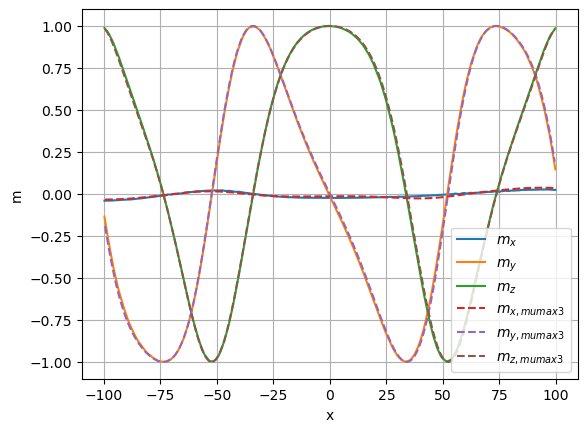

In [12]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.interpolate import RegularGridInterpolator
import pyvista as pv
import numpy as np
np.bool = np.bool_
import math
import glob
import matplotlib.pyplot as plt


np.bool = np.bool_
h5files = glob.glob("relax_GPU/*.h5")

data_Fenicsx = []
p = 0

with h5py.File(h5files[-1], "r") as h5:
    # Nodes
    points = h5["Mesh/Grid/geometry"][:]   

    # TTopology
    cells = h5["Mesh/Grid/topology"][:]    

    # Magnetization
    m = h5["Function/f/0"][:] 

points[:,2] = points[:,2] - 50

x = points[:,0]

mx = m[:,0]
my = m[:,1]
mz = m[:,2]


num_cells = cells.shape[0]

cells_pv = np.hstack([
    np.full((num_cells, 1), 4),
    cells
]).astype(np.int64).ravel()

celltypes = np.full(num_cells, pv.CellType.TETRA, dtype=np.uint8)


mesh_fem = pv.UnstructuredGrid(cells_pv, celltypes, points)


mesh_fem.point_data["m"] = m
mesh_fem.point_data["mx"] = mx
mesh_fem.point_data["my"] = my
mesh_fem.point_data["mz"] = mz


# Line along x and y=z=-0.5 nm


punto_inicial = (x.min()+0.2, -0.5, -0.5)
punto_final   = (x.max()-0.2, -0.5, -0.5)

linea_fem = mesh_fem.sample_over_line(
    punto_inicial,
    punto_final,
    resolution=500
)

x_line_fem  = linea_fem.points[:, 0]
mx_line_fem = linea_fem["mx"]
my_line_fem = linea_fem["my"]
mz_line_fem = linea_fem["mz"]

# We performed the same simulation using MuMax3 with a cell size of 1x1x1 nm^3. The resulting magnetization state is loaded for comparison.

x_line, mx_line, my_line, mz_line = np.loadtxt("data.txt")

plt.plot(x_line_fem, mx_line_fem, label="$m_x$")
plt.plot(x_line_fem, my_line_fem, label="$m_y$")
plt.plot(x_line_fem, mz_line_fem, label="$m_z$")

plt.plot(x_line, mx_line,"--" ,  label="$m_{x,mumax3}$ " )
plt.plot(x_line, my_line, "--" , label="$m_{y,mumax3}$ " )
plt.plot(x_line, mz_line,  "--", label="$m_{z,mumax3}$")

plt.xlabel("x")
plt.ylabel("m")
plt.legend()
plt.grid(True)
plt.show()